In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend ,resample
from statsmodels.tsa.ar_model import AutoReg
from scipy.signal import find_peaks
from scipy.integrate import simpson
from scipy.signal import periodogram
from sklearn.model_selection import train_test_split
import pywt
import os
import re


# 1. Read files and make CSV

In [2]:
# Configuration
input_folder = '3-class'
class_mapping = {
    'yukari': 'Up',
    'asagi': 'Down',
    'sag': 'Right',
    'sol': 'Left',
    'kirp': 'Blink'
}

def process_and_split_with_trial_numbers(test_size=0.20):
    # 1. Get all .txt files
    if not os.path.exists(input_folder):
        print(f"Error: Folder '{input_folder}' not found.")
        return

    all_files = [f for f in os.listdir(input_folder) if f.endswith('.txt')]
    
    # 2. Extract Unique Trials while keeping their numbers and labels
    # We will store information as a list of dictionaries to easily split later
    unique_trials_info = []
    seen_bases = set()

    for f in all_files:
        lower_f = f.lower()
        for key, val in class_mapping.items():
            if key in lower_f:
                # Extract base name (e.g., asagi10) and trial number (e.g., 10)
                # Regex looks for the key followed by digits
                match = re.search(rf"{key}(\d+)", lower_f)
                if match:
                    trial_num = match.group(1)
                    base_name = f"{key}{trial_num}" # Example: asagi10
                    
                    if base_name not in seen_bases:
                        unique_trials_info.append({
                            'base_name': base_name,
                            'label': val,
                            'number': trial_num
                        })
                        seen_bases.add(base_name)
                break

    # 3. Split the trials (Unique Trials) to ensure H/V stay together
    train_info, test_info = train_test_split(
        unique_trials_info,
        test_size=test_size,
        random_state=42,
        stratify=[t['label'] for t in unique_trials_info]
    )

    def build_dataset(info_list):
        data_rows = []
        for info in info_list:
            base = info['base_name']
            # Search for the H and V files associated with this trial base
            for suffix in ['h.txt', 'v.txt']:
                target_filename = base + suffix
                # Case-insensitive match in the file list
                actual_file = next((f for f in all_files if f.lower() == target_filename), None)
                
                if actual_file:
                    file_path = os.path.join(input_folder, actual_file)
                    with open(file_path, 'r') as f:
                        signal = [int(line.strip()) for line in f if line.strip()]
                    
                    # Construct the row with ALL metadata
                    row = {
                        'Trial_ID': actual_file.replace('.txt', ''),
                        'Trial_Number': info['number'],
                        'Label': info['label'],
                        'Channel': 'H' if 'h' in suffix else 'V'
                    }
                    # Add signal points
                    for i, v in enumerate(signal):
                        row[f'Point_{i}'] = v
                    data_rows.append(row)
        
        return pd.DataFrame(data_rows)

    # 4. Generate DataFrames
    train_df = build_dataset(train_info)
    test_df = build_dataset(test_info)

    # Reorder columns to make sure metadata is at the beginning
    def reorder(df):
        if df.empty: return df
        metadata = ['Trial_ID', 'Trial_Number', 'Label', 'Channel']
        points = sorted([c for c in df.columns if c.startswith('Point_')], 
                        key=lambda x: int(x.split('_')[1]))
        return df[metadata + points]

    train_df = reorder(train_df)
    test_df = reorder(test_df)

    # 5. Save files
    train_df.to_csv('EOG_train.csv', index=False)
    test_df.to_csv('EOG_test.csv', index=False)
    
    print("Files saved successfully with Trial_Number column!")
    print(f"Training trials: {len(train_info)} | Testing trials: {len(test_info)}")


In [3]:
process_and_split_with_trial_numbers(test_size=0.20)

Files saved successfully with Trial_Number column!
Training trials: 80 | Testing trials: 20


# 2. Read CSV file

In [4]:
data_path_train = 'EOG_train.csv'
data_path_test = 'EOG_test.csv'

In [5]:
import pandas as pd
import numpy as np

def load_csv_to_paired_dictionary(csv_path):
    # 1. Read the CSV file
    df = pd.read_csv(csv_path)
    
    # 2. Create the dictionary to hold the results
    current_data = {}
    
    # 3. Group data by 'Trial_Number' and 'Label' to pair H and V rows
    grouped = df.groupby(['Trial_Number', 'Label'])
    
    for (trial_num, label), group in grouped:
        # Get all columns that start with 'Point_'
        signal_cols = [c for c in df.columns if c.startswith('Point_')]
        
        # Extract Horizontal (H) and Vertical (V) data for this specific trial
        h_row = group[group['Channel'] == 'H']
        v_row = group[group['Channel'] == 'V']
        
        # Convert the row values into a 1D Numpy array
        # We use .iloc[0] because we expect only one H and one V per trial
        if not h_row.empty and not v_row.empty:
            h_sig = h_row[signal_cols].values.flatten()
            v_sig = v_row[signal_cols].values.flatten()
            
            # Use the label as the dictionary key (or f"{label}_{trial_num}" for uniqueness)
            dict_key = f"{label}_{trial_num}"
            current_data[dict_key] = [h_sig, v_sig]
            
    return current_data

In [6]:
train_data = load_csv_to_paired_dictionary(data_path_train)
test_data = load_csv_to_paired_dictionary(data_path_test)

In [7]:
if train_data:
    sample_key = list(train_data.keys())[0]
    print(f"Loaded {len(train_data)} paired trials.")
    print(f"Example Key: {sample_key}")
    print(f"H-Signal shape: {train_data[sample_key][0].shape}")
    print(f"V-Signal shape: {train_data[sample_key][1].shape}")

Loaded 80 paired trials.
Example Key: Down_1
H-Signal shape: (251,)
V-Signal shape: (251,)


In [8]:
if test_data:
    sample_key1 = list(test_data.keys())[0]
    print(f"Loaded {len(test_data)} paired trials.")
    print(f"Example Key: {sample_key1}")
    print(f"H-Signal shape: {test_data[sample_key1][0].shape}")
    print(f"V-Signal shape: {test_data[sample_key1][1].shape}")

Loaded 20 paired trials.
Example Key: Blink_1
H-Signal shape: (251,)
V-Signal shape: (251,)


In [9]:
train_data

{'Down_1': [array([134, 141, 138, 131, 139, 143, 134, 137, 141, 131, 135, 142, 140,
         133, 141, 142, 134, 142, 144, 139, 134, 141, 136, 131, 138, 138,
         129, 133, 137, 128, 133, 133, 127, 127, 135, 130, 127, 131, 133,
         123, 127, 133, 132, 127, 132, 135, 128, 132, 132, 130, 131, 135,
         129, 129, 131, 134, 132, 133, 139, 131, 138, 136, 133, 134, 136,
         129, 132, 143, 134, 128, 138, 135, 132, 137, 141, 135, 133, 139,
         139, 132, 137, 139, 127, 139, 139, 132, 136, 139, 137, 131, 142,
         139, 133, 137, 141, 134, 134, 125, 121, 112, 117, 109, 100, 101,
         100,  91,  90,  92,  85,  92,  90,  87,  93,  93,  88,  94,  93,
          96, 107, 114, 129, 145, 147, 146, 152, 153, 142, 145, 144, 141,
         143, 147, 143, 141, 146, 146, 142, 146, 150, 143, 142, 149, 143,
         143, 150, 152, 141, 149, 152, 143, 147, 149, 149, 142, 153, 148,
         140, 150, 152, 145, 150, 154, 144, 146, 152, 147, 144, 147, 150,
         145, 145, 152, 145,

In [10]:
test_data

{'Blink_1': [array([140, 135, 135, 143, 138, 134, 141, 140, 135, 140, 139, 133, 135,
         139, 137, 129, 135, 137, 132, 136, 139, 135, 134, 137, 133, 131,
         134, 137, 125, 134, 135, 129, 129, 137, 129, 127, 134, 134, 127,
         130, 133, 125, 131, 136, 130, 127, 135, 132, 128, 132, 133, 125,
         131, 133, 124, 126, 133, 130, 126, 132, 133, 125, 130, 131, 124,
         126, 129, 128, 122, 130, 129, 123, 127, 132, 120, 126, 128, 124,
         122, 127, 124, 120, 130, 137, 145, 162, 170, 168, 157, 158, 151,
         140, 142, 142, 134, 137, 136, 130, 129, 134, 131, 126, 130, 130,
         120, 124, 128, 124, 122, 130, 126, 121, 128, 127, 120, 126, 126,
         121, 123, 127, 124, 121, 127, 126, 119, 125, 126, 120, 123, 126,
         124, 118, 125, 125, 118, 124, 124, 118, 120, 125, 121, 116, 124,
         125, 117, 123, 124, 119, 120, 125, 119, 120, 125, 123, 117, 125,
         124, 119, 122, 128, 120, 119, 125, 125, 119, 123, 124, 118, 120,
         125, 119, 120, 128

# 3. Plot signal

In [11]:
def plot_complex_grid(data_dict, rows=20, cols=5):
    trial_keys = list(data_dict.keys())
    total_plots = rows * cols
    
    # Create a large figure
    # Width = 4 units per column, Height = 3 units per row
    fig = plt.figure(figsize=(cols * 4, rows * 3))
    
    for i in range(min(total_plots, len(trial_keys))):
        key = trial_keys[i]
        h_signal = data_dict[key][0]
        v_signal = data_dict[key][1]
        
        # Calculate position for the H signal (Top part of the cell)
        # We use a grid of (rows*2) to stack H and V
        ax_h = plt.subplot(rows * 2, cols, i + 1 + (i // cols) * cols)
        ax_h.plot(h_signal, color='blue', linewidth=0.7)
        ax_h.set_title(f"Trial: {key}", fontsize=8)
        ax_h.tick_params(axis='both', which='both', labelsize=7)
        ax_h.grid(True, alpha=0.2)
        
        # Calculate position for the V signal (Bottom part of the cell)
        ax_v = plt.subplot(rows * 2, cols, i + 1 + (i // cols + 1) * cols)
        ax_v.plot(v_signal, color='red', linewidth=0.7)
        ax_v.tick_params(axis='both', which='both', labelsize=7)
        ax_v.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

def plot_wavelet_grid(X_wavelet, y_labels, rows=10, cols=5):
    total_samples = X_wavelet.shape[0]
    total_plots = min(rows * cols, total_samples)
    
    # Calculate the midpoint because H and V are concatenated
    # Since X_wavelet is [H_features, V_features], the middle index is:
    mid_point = X_wavelet.shape[1] // 2
    
    fig = plt.figure(figsize=(cols * 4, rows * 3))
    
    for i in range(total_plots):
        # Extract the combined row
        feature_row = X_wavelet[i]
        label = y_labels[i]
        
        # Split back into H and V parts
        h_wave = feature_row[:mid_point]
        v_wave = feature_row[mid_point:]
        
        # Position for H (Top)
        ax_h = plt.subplot(rows * 2, cols, i + 1 + (i // cols) * cols)
        ax_h.plot(h_wave, color='blue', linewidth=0.7)
        ax_h.set_title(f"Idx:{i} | {label}", fontsize=8)
        ax_h.tick_params(labelsize=7)
        ax_h.grid(True, alpha=0.2)
        
        # Position for V (Bottom)
        ax_v = plt.subplot(rows * 2, cols, i + 1 + (i // cols + 1) * cols)
        ax_v.plot(v_wave, color='red', linewidth=0.7)
        ax_v.tick_params(labelsize=7)
        ax_v.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

import matplotlib.pyplot as plt
import numpy as np

def plot_psd_grid_final(f_axis, X_psd, y_labels, rows=10, cols=5):
    total_samples = X_psd.shape[0]
    total_plots = min(rows * cols, total_samples)
    
    # Each row in X_psd is [H_psd, V_psd], so one channel length is total_cols // 2
    num_features_per_channel = X_psd.shape[1] // 2
    
    # Ensure the frequency axis length matches the PSD data length
    # If there's a slight difference, we slice f_axis to match
    f_plot = f_axis[:num_features_per_channel]

    fig = plt.figure(figsize=(cols * 4, rows * 3))
    
    for i in range(total_plots):
        feature_row = X_psd[i]
        label = y_labels[i]
        
        # Split concatenated features into H and V
        h_psd = feature_row[:num_features_per_channel]
        v_psd = feature_row[num_features_per_channel:]
        
        # --- Horizontal Channel Subplot ---
        ax_h = plt.subplot(rows * 2, cols, i + 1 + (i // cols) * cols)
        ax_h.semilogy(f_plot, h_psd, color='blue', linewidth=0.8) 
        ax_h.set_title(f"Idx:{i} | {label}", fontsize=8)
        ax_h.tick_params(labelsize=7)
        ax_h.grid(True, which='both', alpha=0.2)
        
        # --- Vertical Channel Subplot ---
        ax_v = plt.subplot(rows * 2, cols, i + 1 + (i // cols + 1) * cols)
        ax_v.semilogy(f_plot, v_psd, color='red', linewidth=0.8)
        ax_v.set_xlabel("Freq (Hz)", fontsize=7)
        ax_v.tick_params(labelsize=7)
        ax_v.grid(True, which='both', alpha=0.2)

    plt.tight_layout()
    plt.show()


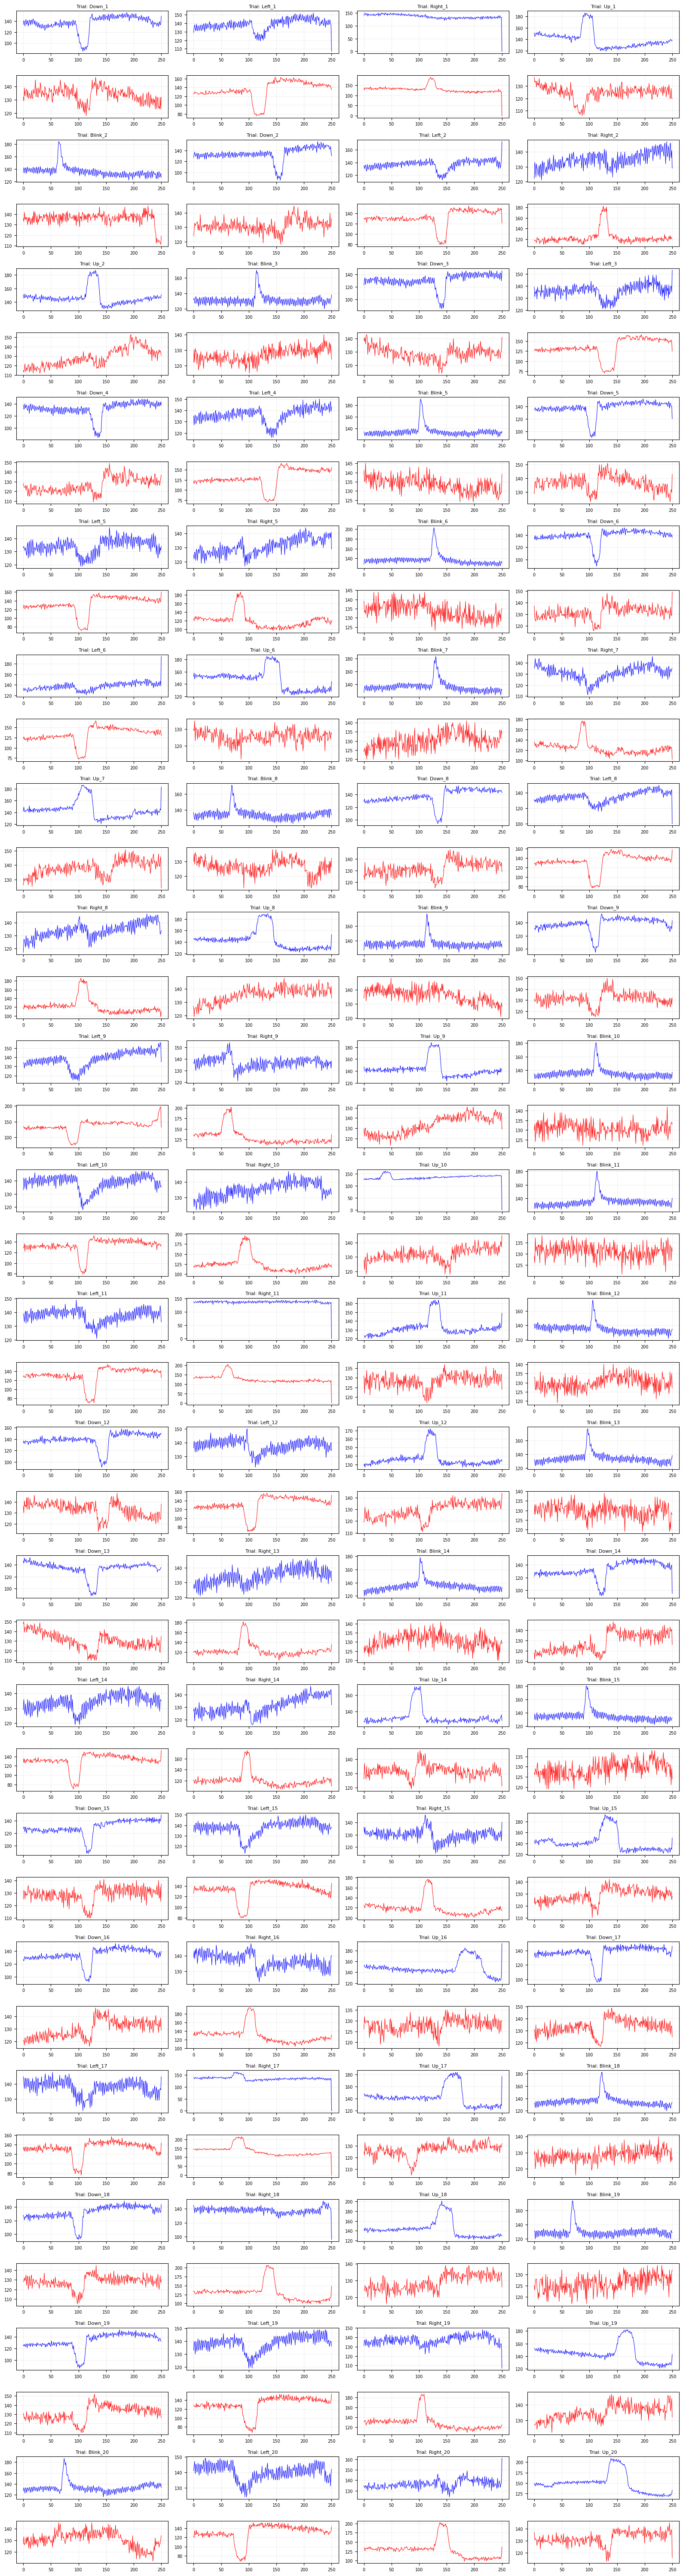

In [12]:
plot_complex_grid(train_data, rows=20, cols=4)

# 4. preprocessing

In [13]:
def butter_bandpass_filter(Input_Signal,Low_cutoff,High_Cutoff,Sampling_Rate,order):
    nyq=0.5*Sampling_Rate
    low=Low_cutoff/nyq
    high=High_Cutoff/nyq
    Numeator,denminator = butter(order,[low,high],btype='band',analog=False,fs=None)
    filtered=filtfilt(Numeator,denminator,Input_Signal)
    return filtered

In [14]:
preprocess_train_signal = {}
for label in train_data:
    preprocess_train_signal[label] = [butter_bandpass_filter(sig,Low_cutoff=0.5,High_Cutoff=20,Sampling_Rate=176,order=2) for sig in train_data[label]]

In [15]:
preprocess_test_signal = {}
for label in test_data:
    preprocess_test_signal[label] = [butter_bandpass_filter(sig,Low_cutoff=0.5,High_Cutoff=20,Sampling_Rate=176,order=2) for sig in test_data[label]]

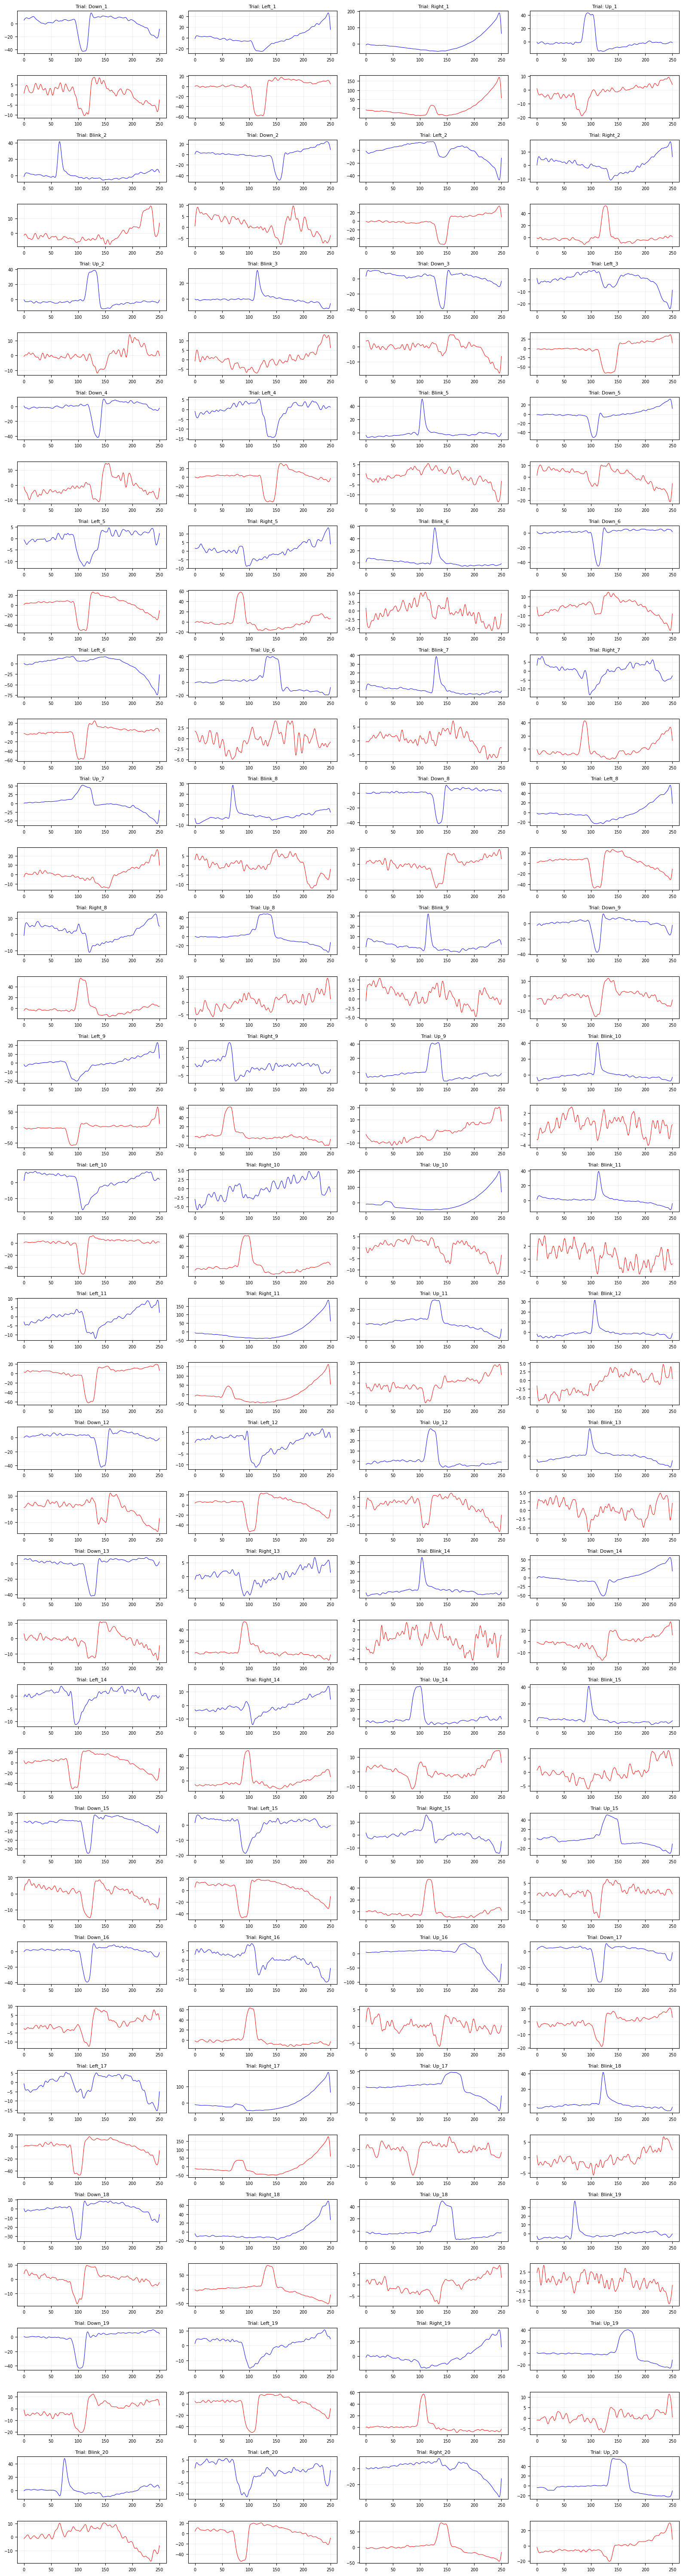

In [16]:
plot_complex_grid(preprocess_train_signal, rows=20, cols=4)

In [17]:
preprocess_train_signal

{'Down_1': [array([  5.22560881,   6.72393833,   7.78369729,   8.45154709,
           8.90333585,   9.03510621,   8.76233325,   8.26677597,
           7.79269552,   7.59450407,   7.85960407,   8.41503658,
           8.92053322,   9.33741052,   9.79202976,  10.26202712,
          10.68918466,  10.97558595,  10.84562989,  10.15489803,
           9.13487616,   8.07280364,   7.10519554,   6.3409372 ,
           5.75927854,   5.16181982,   4.49991517,   3.88853324,
           3.30023757,   2.64705193,   1.95263347,   1.28264386,
           0.78074232,   0.59802473,   0.60470443,   0.51042084,
           0.23562703,  -0.15507449,  -0.59958434,  -0.86309819,
          -0.65333128,  -0.05167458,   0.59292786,   1.12221919,
           1.53616527,   1.75774228,   1.76750752,   1.69473183,
           1.63172822,   1.5799194 ,   1.49550528,   1.30645874,
           1.08001382,   1.09024257,   1.53307927,   2.3275444 ,
           3.27666786,   4.20508161,   4.93085041,   5.3292901 ,
           5.37

# 5. Raw Features

In [18]:
def create_raw_arrays(data_dict):
    X_list = []
    y_list = []
    
    for key, signals in data_dict.items():
        label = key.split('_')[0]
        
        # signals[0]  Horizontal
        # signals[1]  Vertical
        h_sig = signals[0]
        v_sig = signals[1]
        
        combined_signal = np.concatenate([h_sig, v_sig])
        
        X_list.append(combined_signal)
        y_list.append(label)
    
    return np.array(X_list), np.array(y_list)


In [19]:
X_train_raw, y_train = create_raw_arrays(preprocess_train_signal)
X_test_raw, y_test = create_raw_arrays(preprocess_test_signal)

In [20]:
print(f"X_train_raw shape: {X_train_raw.shape}") 
print(f"y_train shape: {y_train.shape}")

X_train_raw shape: (80, 502)
y_train shape: (80,)


In [21]:
X_train_raw

array([[ 5.22560881e+00,  6.72393833e+00,  7.78369729e+00, ...,
        -7.18641855e+00, -5.15410708e+00, -2.52329718e+00],
       [-9.64193057e-01,  1.63065258e+00,  3.41820627e+00, ...,
         9.62190668e+00,  7.36971744e+00,  4.65928144e+00],
       [-6.33697577e+00, -3.41027357e+00, -1.43088772e+00, ...,
         1.44854279e+02,  1.07438977e+02,  5.76955315e+01],
       ...,
       [ 1.35877916e+00,  2.65843764e+00,  3.50760196e+00, ...,
        -1.78344225e+01, -1.38262032e+01, -8.86689448e+00],
       [ 9.80582111e-01,  4.17470862e-01, -4.19221713e-02, ...,
        -3.84214709e+01, -2.89232436e+01, -1.64004075e+01],
       [-3.66340778e+00, -3.93343136e+00, -4.02654998e+00, ...,
         2.41442944e+01,  1.72884143e+01,  8.16030376e+00]])

In [22]:
y_train

array(['Down', 'Left', 'Right', 'Up', 'Blink', 'Down', 'Left', 'Right',
       'Up', 'Blink', 'Down', 'Left', 'Down', 'Left', 'Blink', 'Down',
       'Left', 'Right', 'Blink', 'Down', 'Left', 'Up', 'Blink', 'Right',
       'Up', 'Blink', 'Down', 'Left', 'Right', 'Up', 'Blink', 'Down',
       'Left', 'Right', 'Up', 'Blink', 'Left', 'Right', 'Up', 'Blink',
       'Left', 'Right', 'Up', 'Blink', 'Down', 'Left', 'Up', 'Blink',
       'Down', 'Right', 'Blink', 'Down', 'Left', 'Right', 'Up', 'Blink',
       'Down', 'Left', 'Right', 'Up', 'Down', 'Right', 'Up', 'Down',
       'Left', 'Right', 'Up', 'Blink', 'Down', 'Right', 'Up', 'Blink',
       'Down', 'Left', 'Right', 'Up', 'Blink', 'Left', 'Right', 'Up'],
      dtype='<U5')

# 6. Feature Extraction

In [23]:
def ExtractMixFeatures(signal):
    """
    Extracts a combination of Morphological and Statistical features 
    from the time domain signal.
    """
    # --- Morphological Features ---
    peaks, _ = find_peaks(signal)
    if len(peaks) > 0:
        max_peak = np.max(signal[peaks])
    else:
        max_peak = np.max(signal)
        
    # Calculate Area Under the Curve (AUC) using Simpson's rule
    area = simpson(signal)
    
    # --- Statistical Features ---
    mu = np.mean(signal)
    # Calculate the variance (measure of signal spread)
    var = np.var(signal)
    std = np.std(signal)
    
    return [max_peak, area, mu, var, std]

In [24]:
def build_mix_features_matrix(data_dict):
    X_mix = []
    
    for key, signals in data_dict.items():
        h_sig = signals[0]
        v_sig = signals[1]
        
        # 1. Extract features for Horizontal channel
        h_features = ExtractMixFeatures(h_sig)
        
        # 2. Extract features for Vertical channel
        v_features = ExtractMixFeatures(v_sig)
        
        # 3. Combine them 
        combined_features = np.concatenate([h_features, v_features])
        
        X_mix.append(combined_features)
        
    return np.array(X_mix)

In [25]:
X_train_mix = build_mix_features_matrix(train_data)
X_test_mix = build_mix_features_matrix(test_data)

In [26]:
print(f"X_train_mix shape: {X_train_mix.shape}") 
print(f"X_test_mix shape: {X_test_mix.shape}")  

X_train_mix shape: (80, 10)
X_test_mix shape: (20, 10)


In [27]:
def extract_wavelet_features(signal):
    """
    Fs = 176 Hz, Level = 2.
    Extracts cA2 coefficients covering the 0-22 Hz range.
    """
    coeffs = pywt.wavedec(signal, 'db1', level=2)
    wavelet_features = coeffs[0]
    
    return wavelet_features

In [28]:
def build_wavelet_features_matrix(data_dict):
    X_wavelet = []
    
    for key, signals in data_dict.items():
        h_sig = signals[0]
        v_sig = signals[1]
        
        # 1. Extract wavelet coefficients for both channels
        h_wave = extract_wavelet_features(h_sig)
        v_wave = extract_wavelet_features(v_sig)
        
        # 2. Concatenate H and V wavelet features
        # This will create a long row containing [H_wavelet_coeffs, V_wavelet_coeffs]
        combined_wavelet = np.concatenate([h_wave, v_wave])
        
        X_wavelet.append(combined_wavelet)
        
    return np.array(X_wavelet)

In [29]:
X_train_wavelet = build_wavelet_features_matrix(train_data)
X_test_wavelet = build_wavelet_features_matrix(test_data)

In [30]:
print(f"X_train_wavelet shape: {X_train_wavelet.shape}")
print(f"X_test_wavelet shape: {X_test_wavelet.shape}")

X_train_wavelet shape: (80, 126)
X_test_wavelet shape: (20, 126)


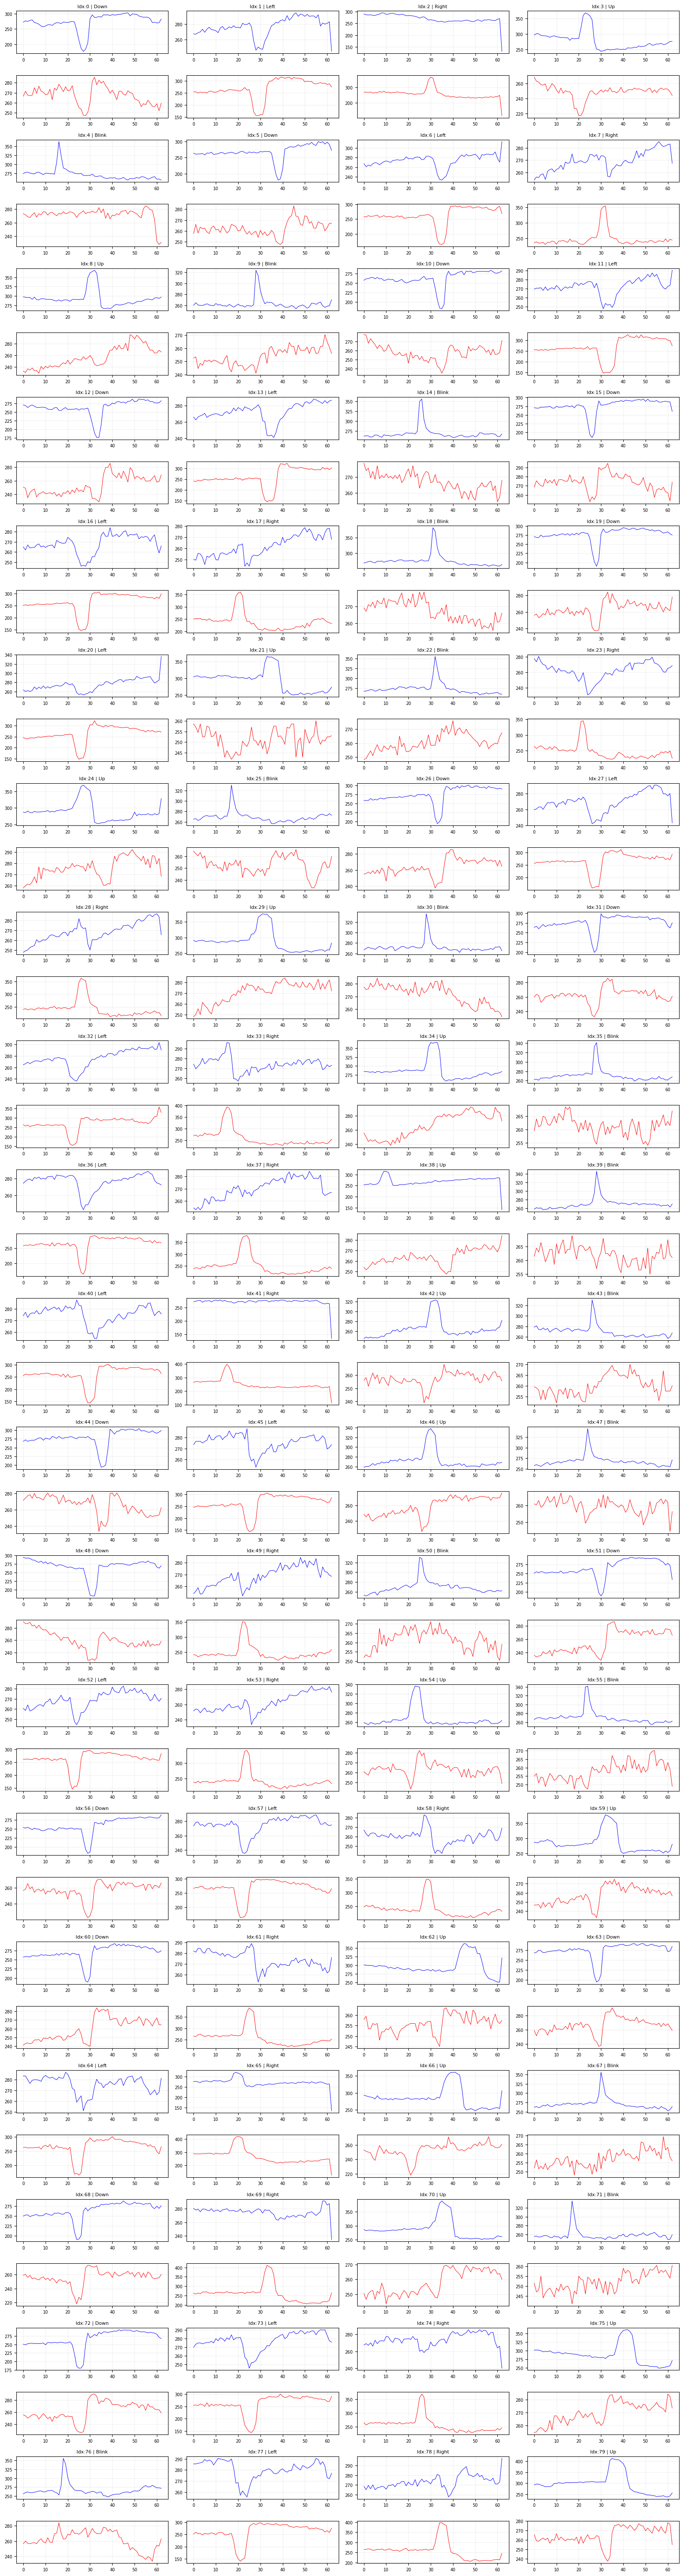

In [31]:
plot_wavelet_grid(X_train_wavelet,y_train,rows=20, cols=4)

In [32]:
def extract_ar_features(signal, lags=10):  

    model = AutoReg(signal, lags=lags).fit()
    
    return model.params 

In [33]:
def build_ar_features_matrix(data_dict, lags):
    X_ar = []
    
    for key, signals in data_dict.items():
        h_sig = signals[0]
        v_sig = signals[1]
        
        # 1. Extract ar coefficients for both channels
        h_ar = extract_ar_features(h_sig, lags)
        v_ar = extract_ar_features(v_sig, lags)
        
        # 2. Concatenate H and V ar features
        combined_ar = np.concatenate([h_ar, v_ar])
        
        X_ar.append(combined_ar)
        
    return np.array(X_ar)

In [34]:
X_train_autoreg = build_ar_features_matrix(train_data,14)
X_test_autoreg = build_ar_features_matrix(test_data,14)

In [35]:
print(f"X_train_autoreg shape: {X_train_autoreg.shape}")
print(f"X_test_autoreg shape: {X_test_autoreg.shape}")

X_train_autoreg shape: (80, 30)
X_test_autoreg shape: (20, 30)


In [36]:
import scipy
def extract_psd_features(signal, fs=176):
    
    f, psd = scipy.signal.periodogram(signal, fs, scaling='density')    
    # relevant_indices = np.where(f <= 20)[0]
    # psd_features = psd[relevant_indices]
    
    return f, psd

In [37]:
def build_psd_features_matrix(data_dict):
    X_psd = []
    f_axis = None
    
    for key, signals in data_dict.items():
        h_sig = signals[0]
        v_sig = signals[1]
        
        # 1. Extract psd coefficients for both channels
        f,h_psd = extract_psd_features(h_sig)
        _,v_psd = extract_psd_features(v_sig)

        # Save f_axis once to use it later for plotting
        if f_axis is None:
            f_axis = f
        
        # 2. Concatenate H and V psd features
        combined_psd = np.concatenate([h_psd, v_psd])
        
        X_psd.append(combined_psd)
        
    return f_axis, np.array(X_psd)

In [38]:
f_vals, X_train_psd = build_psd_features_matrix(train_data)
_, X_test_psd = build_psd_features_matrix(test_data)

In [39]:
print(f"X_train_psd shape: {X_train_psd.shape}")
print(f"X_test_psd shape: {X_test_psd.shape}")

X_train_psd shape: (80, 252)
X_test_psd shape: (20, 252)


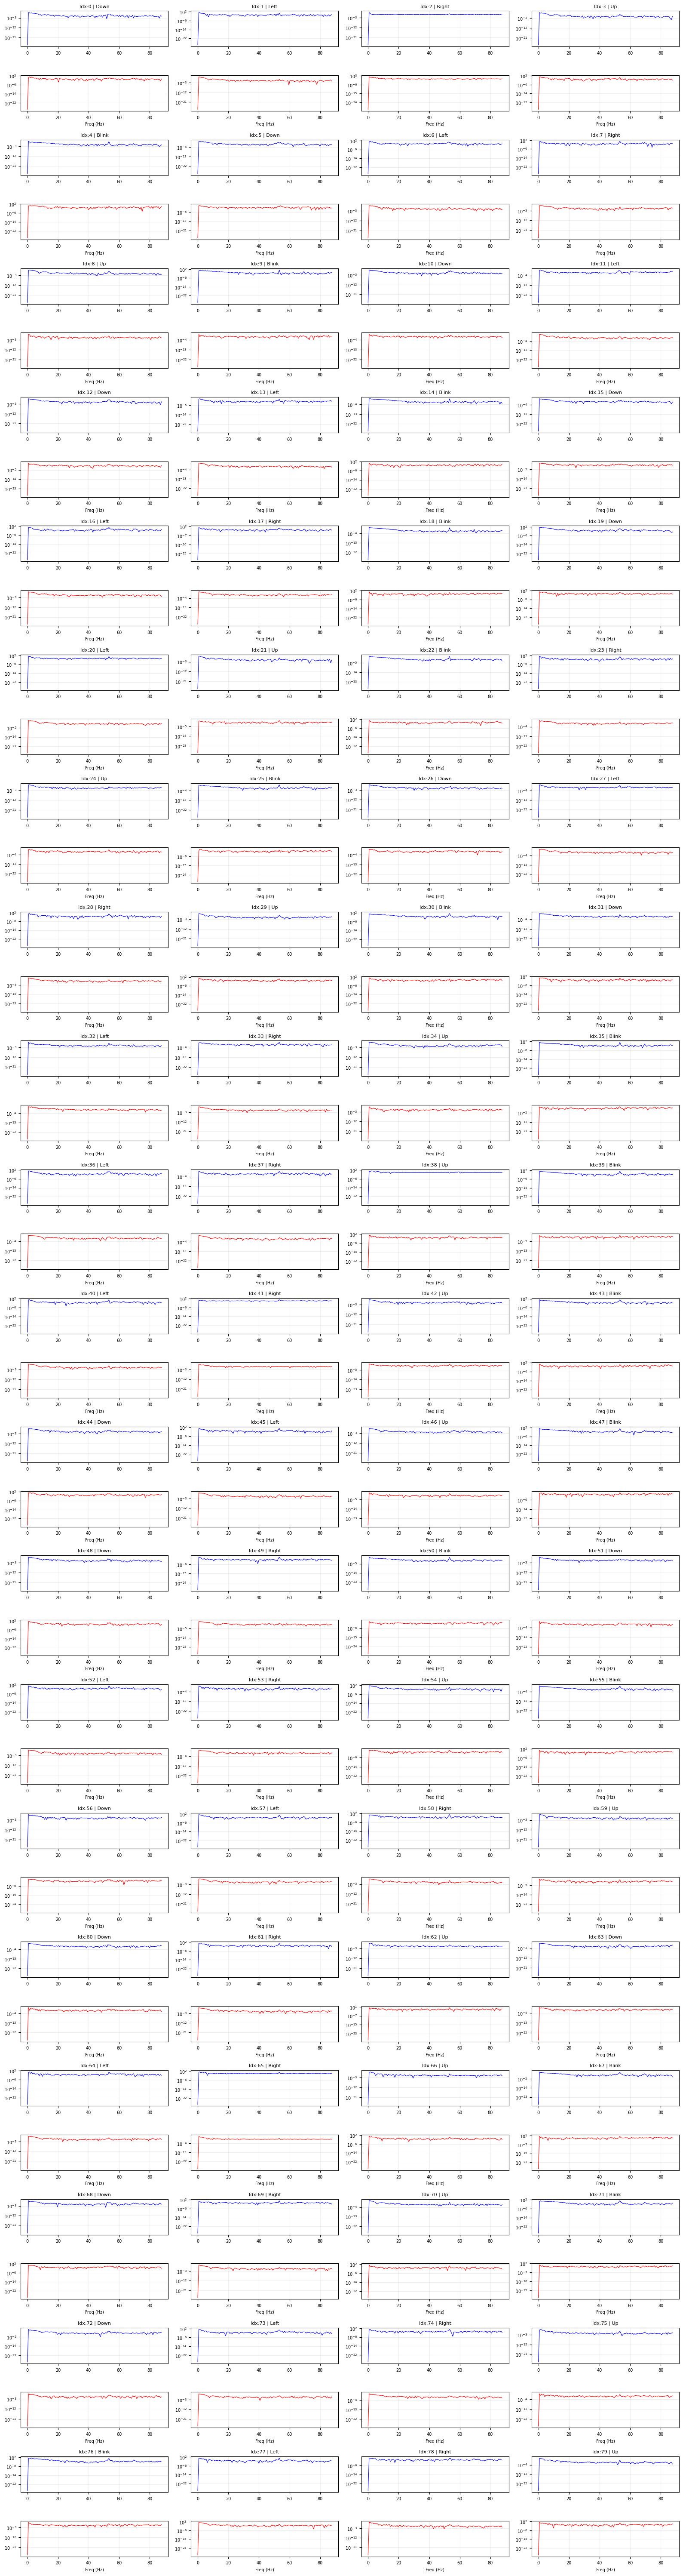

In [40]:
plot_psd_grid_final(f_vals,X_train_psd,y_train, rows=20, cols=4)

In [41]:
# def extract_ar_features2(signal, lags=10):
#     from scipy.signal import detrend
#     import numpy as np
#     from statsmodels.tsa.ar_model import AutoReg
    
#     signal = detrend(signal)
#     std = np.std(signal)
    
#     if std == 0:
#         return np.zeros(lags)
    
#     signal = (signal - np.mean(signal)) / std
    
#     model = AutoReg(signal, lags=lags).fit()
    
#     return model.params  

# Apply SVM Classification for each feature

In [42]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# ========= OvO Model =========
def train_and_evaluate_ovo(X_train, X_test, y_train, y_test, feature_name):
    model = make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', decision_function_shape='ovo', C=1, gamma='scale')
    )

    # 1. Train the model
    model.fit(X_train, y_train)

    # 2. Predict on Train data (To get Train Accuracy)
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)

    # 3. Predict on Test data (To get Test Accuracy)
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)

    # 4. Cross Validation (On Train set)
    cv_score = cross_val_score(model, X_train, y_train, cv=5).mean()

    # Improved Print Statement
    print(f"{feature_name:10} -> Train Acc: {train_acc*100:6.2f}% | Test Acc: {test_acc*100:6.2f}% | CV: {cv_score*100:6.2f}%")

    return test_acc
    
# ========= Run All Features =========
accuracies = {}
accuracies["Raw"] = train_and_evaluate_ovo(X_train_raw, X_test_raw, y_train, y_test, "Raw Data")
accuracies["Mix"] = train_and_evaluate_ovo(X_train_mix, X_test_mix, y_train, y_test, "Mix")
accuracies["Wavelet"] = train_and_evaluate_ovo(X_train_wavelet, X_test_wavelet, y_train, y_test, "Wavelet")
accuracies["AR"] = train_and_evaluate_ovo(X_train_autoreg, X_test_autoreg, y_train, y_test, "AR")
accuracies["PSD"] = train_and_evaluate_ovo(X_train_psd, X_test_psd, y_train, y_test, "PSD")

# ========= Best Feature =========
best_feature = max(accuracies, key=accuracies.get)
print(f"\n🔥 Best Feature using OvO SVM: {best_feature} ({accuracies[best_feature]*100:.2f}%)")

Raw Data   -> Train Acc:  97.50% | Test Acc:  85.00% | CV:  91.25%
Mix        -> Train Acc:  95.00% | Test Acc:  95.00% | CV:  93.75%
Wavelet    -> Train Acc:  96.25% | Test Acc:  90.00% | CV:  92.50%
AR         -> Train Acc:  97.50% | Test Acc:  80.00% | CV:  71.25%
PSD        -> Train Acc:  98.75% | Test Acc:  90.00% | CV:  92.50%

🔥 Best Feature using OvO SVM: Mix (95.00%)


In [43]:
# ========= OvR Model =========

def train_and_evaluate_ovr(X_train, X_test, y_train, y_test, feature_name):
    model = make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', C=1, gamma='scale')
    )

    # 1. Train the model
    model.fit(X_train, y_train)

    # 2. Predict on Train data (To get Train Accuracy)
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)

    # 3. Predict on Test data (To get Test Accuracy)
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)

    # 4. Cross Validation (On Train set)
    cv_score = cross_val_score(model, X_train, y_train, cv=5).mean()

    # Improved Print Statement
    print(f"{feature_name:10} -> Train Acc: {train_acc*100:6.2f}% | Test Acc: {test_acc*100:6.2f}% | CV: {cv_score*100:6.2f}%")

    return test_acc
# ========= Run All Features =========
accuracies = {}
accuracies["Raw"] = train_and_evaluate_ovr(X_train_raw, X_test_raw, y_train, y_test, "Raw Data")
accuracies["Mix"] = train_and_evaluate_ovr(X_train_mix, X_test_mix, y_train, y_test, "Mix")
accuracies["Wavelet"] = train_and_evaluate_ovr(X_train_wavelet, X_test_wavelet, y_train, y_test, "Wavelet")
accuracies["AR"] = train_and_evaluate_ovr(X_train_autoreg, X_test_autoreg, y_train, y_test, "AR")
accuracies["PSD"] = train_and_evaluate_ovr(X_train_psd, X_test_psd, y_train, y_test, "PSD")

# ========= Best Feature =========
best_feature = max(accuracies, key=accuracies.get)
print(f"\n🔥 Best Feature using OvR SVM: {best_feature} ({accuracies[best_feature]*100:.2f}%)")

Raw Data   -> Train Acc:  97.50% | Test Acc:  85.00% | CV:  91.25%
Mix        -> Train Acc:  95.00% | Test Acc:  95.00% | CV:  93.75%
Wavelet    -> Train Acc:  96.25% | Test Acc:  90.00% | CV:  92.50%
AR         -> Train Acc:  97.50% | Test Acc:  80.00% | CV:  71.25%
PSD        -> Train Acc:  98.75% | Test Acc:  90.00% | CV:  92.50%

🔥 Best Feature using OvR SVM: Mix (95.00%)


In [44]:
# Save the final model for use in the user interface (calculator_ui.py)
import joblib
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Here we set up the model for the Wavelet data
final_model = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=1, gamma='scale')
)

# Train the model
final_model.fit(X_train_wavelet, y_train)

# Save the model to a file
joblib.dump(final_model, 'eog_model.pkl')
print('Model successfully saved as eog_model.pkl to be run in the UI!')

Model successfully saved as eog_model.pkl to be run in the UI!


Lags   | Train Acc    | Test Acc     | CV Score    
-------------------------------------------------------
1      |      70.00% |      60.00% |      61.25%
2      |      60.00% |      60.00% |      42.50%
3      |      72.50% |      65.00% |      57.50%
4      |      76.25% |      60.00% |      53.75%
5      |      72.50% |      65.00% |      56.25%
6      |      76.25% |      60.00% |      56.25%
7      |      75.00% |      70.00% |      58.75%
8      |      83.75% |      65.00% |      70.00%
9      |      72.50% |      60.00% |      56.25%
10     |      88.75% |      65.00% |      71.25%
11     |      78.75% |      65.00% |      57.50%
12     |      78.75% |      70.00% |      58.75%
13     |      83.75% |      70.00% |      60.00%
14     |      78.75% |      80.00% |      58.75%
15     |      82.50% |      70.00% |      60.00%
16     |      82.50% |      65.00% |      55.00%
17     |      81.25% |      70.00% |      60.00%
18     |      75.00% |      70.00% |      47.50%
19     |  

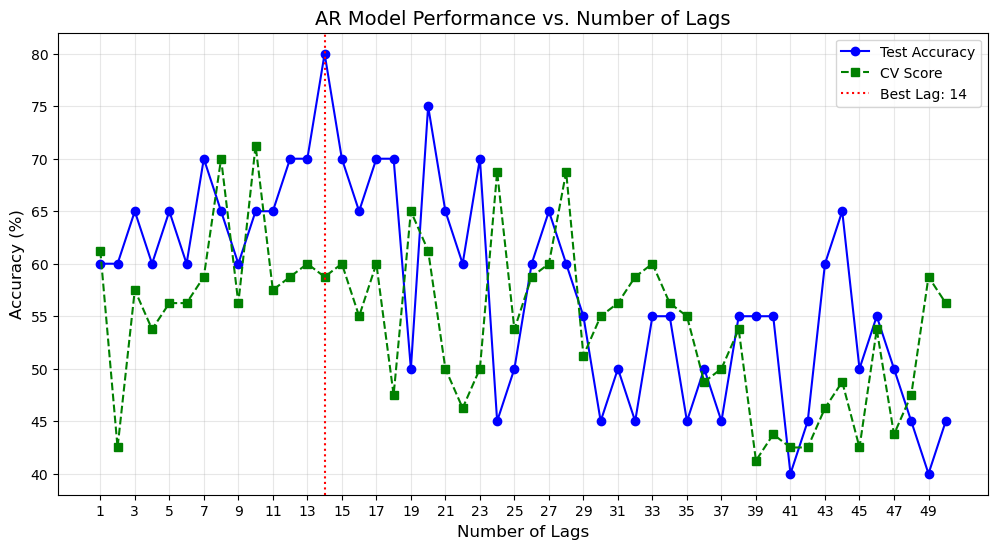


✅ Optimal number of lags found: 14


In [45]:
import matplotlib.pyplot as plt

def find_best_lags(train_data, test_data, y_train, y_test, max_lags=40):
    lags_range = range(1, max_lags + 1)
    test_accs = []
    cv_scores = []
    
    print(f"{'Lags':<6} | {'Train Acc':<12} | {'Test Acc':<12} | {'CV Score':<12}")
    print("-" * 55)

    for lag in lags_range:
        # 1. Build Feature Matrices for current lag
        X_train_ar = build_ar_features_matrix(train_data, lag)
        X_test_ar = build_ar_features_matrix(test_data, lag)
        
        # 2. Evaluate using your existing function
        # Note: I'll modify the print inside the function or just use its return
        model = make_pipeline(StandardScaler(), SVC(kernel='rbf', decision_function_shape='ovo', C=1))
        model.fit(X_train_ar, y_train)
        
        # Calculate scores
        t_acc = accuracy_score(y_test, model.predict(X_test_ar))
        c_score = cross_val_score(model, X_train_ar, y_train, cv=5).mean()
        
        test_accs.append(t_acc)
        cv_scores.append(c_score)
        
        print(f"{lag:<6} | {accuracy_score(y_train, model.predict(X_train_ar))*100:10.2f}% | {t_acc*100:10.2f}% | {c_score*100:10.2f}%")

    # --- Plotting the Results ---
    plt.figure(figsize=(12, 6))
    plt.plot(lags_range, [acc * 100 for acc in test_accs], 'o-', label='Test Accuracy', color='blue')
    plt.plot(lags_range, [score * 100 for score in cv_scores], 's--', label='CV Score', color='green')
    
    # Identify best lag
    best_lag = lags_range[np.argmax(test_accs)]
    plt.axvline(x=best_lag, color='red', linestyle=':', label=f'Best Lag: {best_lag}')
    
    plt.title('AR Model Performance vs. Number of Lags', fontsize=14)
    plt.xlabel('Number of Lags', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.xticks(lags_range[::2]) # Show every 2nd lag for clarity
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return best_lag

best_l = find_best_lags(preprocess_train_signal, preprocess_test_signal, y_train, y_test, max_lags=50)
print(f"\n✅ Optimal number of lags found: {best_l}")